# ftir_18 — transfer roundup: every training-set choice on the same Addis axes

## tl;dr

Answers the deck-review question — the ftir_08 transfer trains on the **916** HIPS-matched
IMPROVE filters; did we also test a model trained on **all** sites, since TOR exists for the
whole pool? — by putting every calibration family on one set of axes (same 239 Addis filters,
HIPS EC-equivalent orientation, MAC = 10; MAC = 6 in the tables). Three results. **(1) A
lineage audit**: ftir_09's "Current IMPROVE TOR EC" is **byte-identical to the smoke-906
calibration** (max |Δ| = 0 across all 239 predictions; the deployed SPARTAN EC is a different
model, corr 0.963) — so phase 2 never actually drew a full-pool TOR transfer on these axes,
and any citation of the ftir_09 numbers (slope 2.30, R² 0.607) should say smoke-906.
**(2) Yes — and it transfers no better**: the no-cleaning full-pool model (13,010 filters,
158 sites, k = 6 raw; retrained per-filter here, reproducing ftir_17's held-out metrics to
1e-9) reads Addis slope **0.60**, intercept **−1.09**, R² **0.691**, RMSE **3.11**,
bias **−3.0 µg/m³** on the 239 available pairs. Thirteen thousand TOR filters buy tracking
(R² 0.69 vs 0.26 for the HIPS-916 transfer) but not calibration: the slope collapses and a
−3 µg/m³ offset remains. **(3) The roundup figure** (`output/plots/deck/transfer_roundup.png`)
shows the three as-is transfers failing in three distinct ways — flat and uninformative
(HIPS-916: 0.22x, R² 0.26), steep with a deep offset (smoke-906: 2.30x − 5.38, the deck's
−6.91 being the fixed-cohort row), compressed low (full pool: 0.60x − 1.09) — while the
bottom row walks toward the local ceiling: deployed 1.90x − 4.17 (R² 0.764), OCEC-800 +
AIRSpec 0.78x − 1.28 (RMSE 2.46), Addis-only nested CV **0.91x + 0.43** (R² 0.883,
RMSE 0.38). No IMPROVE-trained model — 906, 916, or 13,010 samples, TOR or HIPS target —
gets slope and intercept simultaneously right at Addis.

## Context & Methods

Follow-up to a question raised while reviewing the ftir_08 transfer figure (July 2026):
that figure's "IMPROVE model" is trained only on the **916** IMPROVE filters that have a
HIPS Fabs measurement — did we also test a model trained on **all** sites, given that TOR
EC exists for the whole pool? The answer exists, but scattered across four notebooks with
inconsistent axes, cohorts, and — in one case — a misleading label: ftir_09's
"Current IMPROVE TOR EC" turns out to be **byte-identical to the 906-sample smoke
calibration** (audited below), not a full-pool model. This notebook puts every calibration
family on one set of axes: the same Addis filters, the same phase-3 orientation
(HIPS EC-equivalent, Fabs/MAC, on x; predicted EC on y; MAC = 10 headline, MAC = 6 in the
tables).

The six panels:

1. **HIPS-τ transfer (916)** — the ftir_08 left panel: IMPROVE model trained on the 916
   HIPS-matched filters, target HIPS optical depth τ, k = 1 chosen by site holdout.
   Committed predictions, re-expressed as Fabs/10 so it shares axes with the TOR models
   (ftir_08's familiar Fabs-space numbers are these × 10).
2. **Smoke-906 TOR EC** — the reconstructed "current" R model from the FTIR directory
   (Katie-George smoke rows, 140 sites). Committed ftir_09 predictions.
3. **No-cleaning full-pool TOR EC** — every eligible lot-248/251 filter (~13k, all sites,
   no selection), the direct answer to "all sites, TOR target". ftir_17 established its
   metrics but exported no per-filter predictions, so it is retrained here under the
   identical locked protocol (k = 6 raw / k = 5 AIRSpec df1 = 6 from ftir_11/13,
   seed-20260717 site-disjoint split, no Addis information in the fit).
4. **Deployed SPARTAN FTIR EC** — the as-shipped pipeline predictions (fixed 190-filter
   cohort only; corr 0.96 with smoke-906 but not the same model).
5. **Lowest-OCEC 800 + AIRSpec df1 = 6** — phase 3's best candidate (ftir_13 committed
   predictions).
6. **Addis-only HIPS, nested CV** — the ftir_08 right panel: the local-calibration
   ceiling, honest out-of-sample.

Only panel 3 involves any model fitting in this notebook; everything else is read from
committed tables, so the roundup cannot drift from the source notebooks.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit

from phase3_common import (
    PATHS, PHASE2_TABLES, load_addis_evaluation, load_tor_loadings, load_pool_metadata,
)
from pls_transfer import regression_metrics

TABLE_DIR = Path('output/tables/ftir18')
PLOT_DIR = Path('output/plots/ftir18')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SPLIT_SEED = 20260717
K_RAW, K_CORRECTED = 6, 5  # locked in ftir_11 / ftir_13

## Data

### 1. Committed per-filter predictions (ftir_08, ftir_09, phase-2, ftir_13)

In [2]:
etad_eval, X_etad_raw, wn = load_addis_evaluation()
wcols = etad_eval.attrs['wcols']
volume = etad_eval['SampleVolume_m3'].to_numpy(float)

t08 = pd.read_csv(PHASE2_TABLES / 'pls_transfer/addis_hips_transfer_predictions.csv')
t09 = pd.read_csv(PHASE2_TABLES / 'pls_transfer/addis_current_vs_analog_tor_predictions.csv')
phase2_predictions = pd.read_csv(
    PHASE2_TABLES / 'pls_calibration_phase2/addis_calibration_predictions.csv')
t13 = pd.read_csv('output/tables/ftir13/addis_predictions_corrected.csv')

roundup = (
    etad_eval[['MediaId', 'ExternalFilterId', 'Fabs']]
    .merge(t08[['MediaId', 'IMPROVE_HIPS_transfer_prediction',
                'Addis_HIPS_nested_CV_prediction']], on='MediaId', validate='one_to_one')
    .merge(t09[['MediaId', 'EC_current_ugm3']], on='MediaId', validate='one_to_one')
    .merge(phase2_predictions[['MediaId', 'EC_deployed_ugm3', 'EC_smoke_906_ugm3']],
           on='MediaId', validate='one_to_one')
    .merge(t13[['MediaId', 'lowest-OCEC 800, AIRSpec df1=6']],
           on='MediaId', validate='one_to_one')
)
fixed_media = set(phase2_predictions.dropna(axis=0, how='any')['MediaId'])
roundup['in_fixed_phase2_cohort'] = roundup['MediaId'].isin(fixed_media)
assert len(roundup) == len(etad_eval)
assert np.allclose(roundup['Fabs'], etad_eval['Fabs'].to_numpy(float))

# The lineage audit behind the roundup: ftir_09's "Current IMPROVE TOR EC" IS the
# smoke-906 model, and the deployed SPARTAN EC is a different model from both.
current_vs_smoke = float(
    (roundup['EC_current_ugm3'] - roundup['EC_smoke_906_ugm3']).abs().max())
deployed_mask = roundup['EC_deployed_ugm3'].notna()
deployed_vs_smoke_corr = float(roundup.loc[deployed_mask, ['EC_deployed_ugm3',
                                                           'EC_smoke_906_ugm3']]
                               .corr().iloc[0, 1])
audit = pd.DataFrame([
    {'check': 'max |EC_current − EC_smoke_906|', 'value': current_vs_smoke},
    {'check': 'corr(EC_deployed, EC_smoke_906), fixed cohort',
     'value': deployed_vs_smoke_corr},
    {'check': 'n available HIPS pairs', 'value': len(roundup)},
    {'check': 'n fixed phase-2 cohort', 'value': int(roundup['in_fixed_phase2_cohort'].sum())},
])
audit.to_csv(TABLE_DIR / 'current_vs_smoke906_audit.csv', index=False)
assert current_vs_smoke == 0.0
display(audit)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


,check,value
0,max |EC_current − EC_smoke_906|,0.000000
1,"corr(EC_deployed, EC_smoke_906), fixed cohort",0.962816
2,n available HIPS pairs,239.000000
3,n fixed phase-2 cohort,190.000000


### 2. The full-pool no-cleaning model, retrained for per-filter predictions

Identical to the ftir_17 block (same eligibility, same locked split and k), kept verbatim
so the metrics must reproduce `ftir17/no_cleaning_fullpool_metrics.csv`; the only addition
is that the Addis predictions are exported this time.

In [3]:
pool_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
pool_row_for_id = {int(a): i for i, a in enumerate(pool_npz['analysis_id'].astype(int))}
pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       dtype={c: np.float32 for c in wcols}).set_index('AnalysisId')
pool_raw = pool_raw[~pool_raw.index.duplicated()]

etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr_media = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr_media['MediaId'] = etad_npz['media_id'].astype(int)
X_addis_corr = (etad_corr_media.groupby('MediaId').mean()
                .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))

pool_meta = load_pool_metadata().merge(load_tor_loadings(), on=['Site', 'date'],
                                       how='left', validate='many_to_one')
eligible = pool_meta[
    pool_meta['TOR_EC_loading_ug'].gt(0)
    & pool_meta['AnalysisId'].astype(int).isin(pool_row_for_id)
    & pool_meta['AnalysisId'].astype(int).isin(pool_raw.index)
].drop_duplicates('FilterId').copy()
analysis_ids = eligible['AnalysisId'].astype(int).to_numpy()
y_pool = eligible['TOR_EC_loading_ug'].to_numpy(float)
sites_pool = eligible['Site'].to_numpy()
print(f'No-cleaning cohort: {len(eligible)} filters, {eligible.Site.nunique()} sites')

X_pool_raw = pool_raw.loc[analysis_ids, wcols].to_numpy(float)
X_pool_corr = pool_npz['corrected'][[pool_row_for_id[a] for a in analysis_ids]].astype(float)

train_pos, test_pos = next(GroupShuffleSplit(
    n_splits=1, test_size=.20, random_state=SPLIT_SEED).split(eligible, groups=sites_pool))
assert set(sites_pool[train_pos]).isdisjoint(sites_pool[test_pos])

fullpool_heldout = {}
for label, X, X_addis, k, column in (
        ('full pool raw', X_pool_raw, X_etad_raw, K_RAW, 'EC_fullpool_raw_ugm3'),
        ('full pool AIRSpec df1=6', X_pool_corr, X_addis_corr, K_CORRECTED,
         'EC_fullpool_corrected_ugm3')):
    model = PLSRegression(n_components=k, scale=False).fit(X[train_pos], y_pool[train_pos])
    fullpool_heldout[label] = regression_metrics(
        y_pool[test_pos], model.predict(X[test_pos]).ravel())
    roundup[column] = model.predict(X_etad_raw if 'raw' in label else X_addis_corr
                                    ).ravel() / volume

reference = pd.read_csv('output/tables/ftir17/no_cleaning_fullpool_metrics.csv')
for label, heldout in fullpool_heldout.items():
    expected = reference[reference['model'] == label].iloc[0]
    assert abs(heldout['R2'] - expected['heldout_TOR_R2']) < 1e-9, label
print('Held-out TOR tests reproduce ftir_17:',
      {label: round(heldout['R2'], 3) for label, heldout in fullpool_heldout.items()})
roundup.to_csv(TABLE_DIR / 'addis_roundup_predictions.csv', index=False)

No-cleaning cohort: 13010 filters, 158 sites


Held-out TOR tests reproduce ftir_17: {'full pool raw': 0.527, 'full pool AIRSpec df1=6': 0.633}


## Results

### 3. Uniform metrics: every model, both cohorts, both MACs

All rows are EC-equivalent space: x = Fabs/MAC, y = predicted EC (µg/m³). The two
HIPS-native models predict Fabs directly, so their predictions are divided by the same
MAC as the x-axis — their slope and R² are MAC-invariant by construction and their MAC = 6
rows are pure unit rescalings, flagged in the table. ftir_08's familiar Fabs-space numbers
(RMSE 34.4 / 3.8) are the MAC = 10 rows × 10.

In [4]:
MODELS = [
    ('HIPS-τ transfer (916)', 'IMPROVE_HIPS_transfer_prediction', 'HIPS-native'),
    ('Smoke-906 TOR EC', 'EC_smoke_906_ugm3', 'TOR'),
    ('No-cleaning full pool raw (13k)', 'EC_fullpool_raw_ugm3', 'TOR'),
    ('No-cleaning full pool AIRSpec df1=6 (13k)', 'EC_fullpool_corrected_ugm3', 'TOR'),
    ('Deployed SPARTAN FTIR EC', 'EC_deployed_ugm3', 'TOR'),
    ('Lowest-OCEC 800 + AIRSpec df1=6', 'lowest-OCEC 800, AIRSpec df1=6', 'TOR'),
    ('Addis-only HIPS nested CV', 'Addis_HIPS_nested_CV_prediction', 'HIPS-native'),
]
fabs = roundup['Fabs'].to_numpy(float)
fixed_mask = roundup['in_fixed_phase2_cohort'].to_numpy()

metric_rows = []
for name, column, kind in MODELS:
    prediction = roundup[column].to_numpy(float)
    for cohort, cohort_mask in (('available pairs', np.isfinite(prediction)),
                                ('fixed phase-2 cohort',
                                 fixed_mask & np.isfinite(prediction))):
        for mac in (10, 6):
            y = prediction[cohort_mask] / mac if kind == 'HIPS-native' \
                else prediction[cohort_mask]
            metric_rows.append({
                'model': name, 'kind': kind, 'cohort': cohort, 'MAC_m2_g': mac,
                'MAC_invariant': kind == 'HIPS-native',
                **regression_metrics(fabs[cohort_mask] / mac, y),
            })
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(TABLE_DIR / 'transfer_roundup_metrics.csv', index=False)
display(metrics[(metrics['MAC_m2_g'] == 10) & (metrics['cohort'] == 'available pairs')]
        .drop(columns=['MAC_m2_g', 'cohort', 'MAC_invariant']).round(3))

,model,kind,n,slope,intercept,R2,RMSE,MAE,bias,median_bias
0,HIPS-τ transfer (916),HIPS-native,239,0.220,0.494,0.264,3.438,3.301,-3.301,-3.197
4,Smoke-906 TOR EC,TOR,239,2.304,-5.379,0.607,2.701,2.005,0.972,0.370
8,No-cleaning full pool raw (13k),TOR,239,0.599,-1.095,0.691,3.112,3.048,-3.048,-2.995
12,No-cleaning full pool AIRSpec df1=6 (13k),TOR,239,0.353,-0.403,0.555,3.643,3.554,-3.554,-3.485
16,Deployed SPARTAN FTIR EC,TOR,190,1.898,-4.170,0.764,1.487,1.196,0.220,-0.064
20,Lowest-OCEC 800 + AIRSpec df1=6,TOR,239,0.780,-1.283,0.626,2.458,2.371,-2.352,-2.341
24,Addis-only HIPS nested CV,HIPS-native,239,0.912,0.435,0.883,0.382,0.266,0.006,0.000


### 4. The roundup figure

Top row: trained elsewhere, applied as-is (the three naive transfers). Bottom row: the
deployed pipeline, phase 3's targeted-cohort candidate, and the local-calibration ceiling.
MAC = 10 throughout; every panel shares the same square axes.

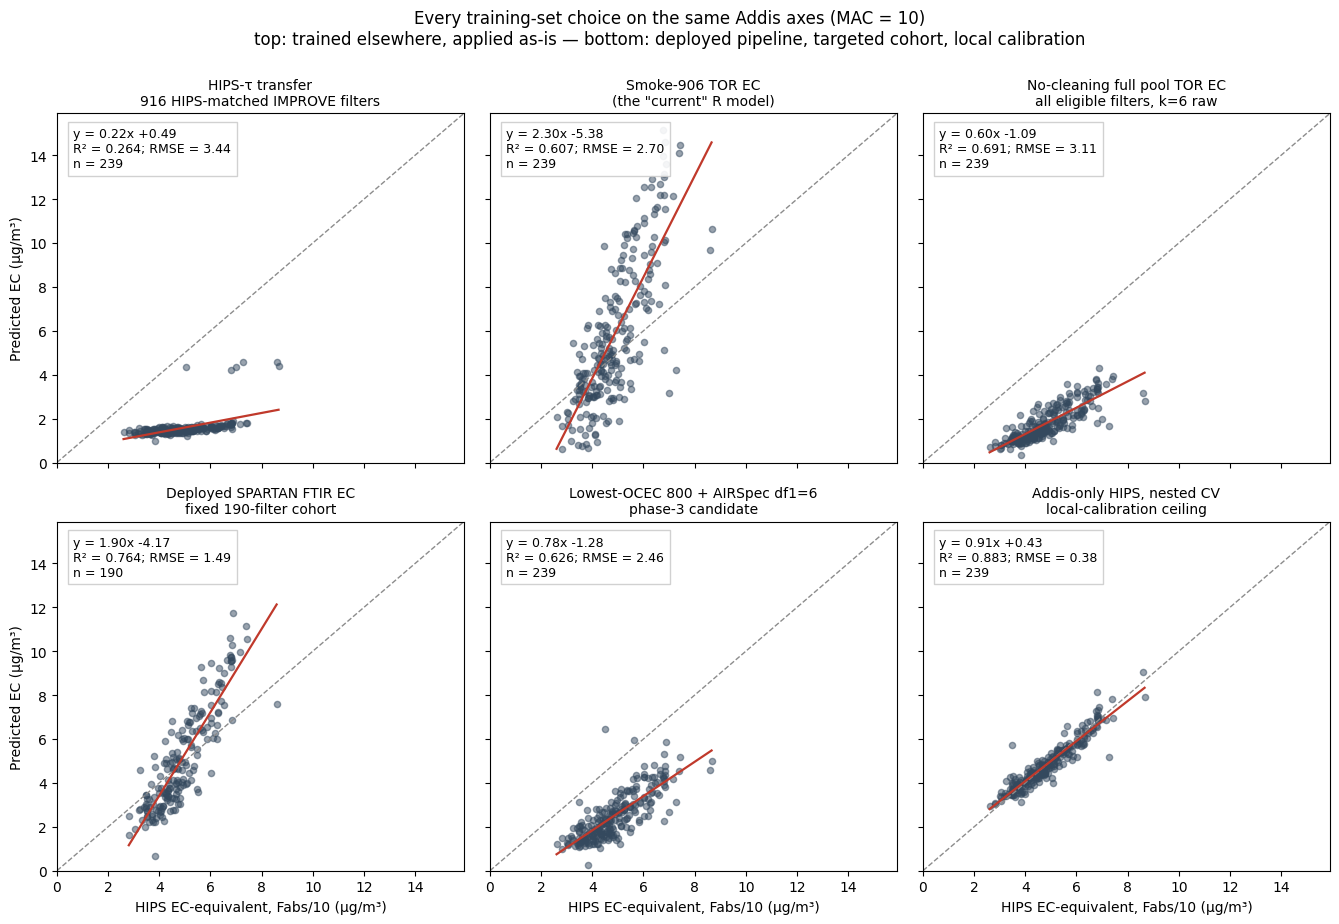

In [5]:
PANELS = [
    ('HIPS-τ transfer\n916 HIPS-matched IMPROVE filters', 'IMPROVE_HIPS_transfer_prediction',
     'HIPS-native'),
    ('Smoke-906 TOR EC\n(the "current" R model)', 'EC_smoke_906_ugm3', 'TOR'),
    ('No-cleaning full pool TOR EC\nall eligible filters, k=6 raw', 'EC_fullpool_raw_ugm3',
     'TOR'),
    ('Deployed SPARTAN FTIR EC\nfixed 190-filter cohort', 'EC_deployed_ugm3', 'TOR'),
    ('Lowest-OCEC 800 + AIRSpec df1=6\nphase-3 candidate', 'lowest-OCEC 800, AIRSpec df1=6',
     'TOR'),
    ('Addis-only HIPS, nested CV\nlocal-calibration ceiling', 'Addis_HIPS_nested_CV_prediction',
     'HIPS-native'),
]
x_all = fabs / 10
hi = float(np.nanmax([np.nanmax(x_all)] +
                     [np.nanmax(roundup[column].to_numpy(float) / (10 if kind == 'HIPS-native'
                                                                   else 1))
                      for _, column, kind in PANELS])) * 1.05

fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.2), sharex=True, sharey=True)
for ax, (title, column, kind) in zip(axes.flat, PANELS):
    prediction = roundup[column].to_numpy(float)
    y_all = prediction / 10 if kind == 'HIPS-native' else prediction
    panel_mask = np.isfinite(y_all)
    stats = regression_metrics(x_all[panel_mask], y_all[panel_mask])
    ax.scatter(x_all[panel_mask], y_all[panel_mask], s=20, alpha=.5, color='#34495E')
    ax.plot([0, hi], [0, hi], '--', color='0.55', lw=1)
    fit_x = np.array([np.nanmin(x_all[panel_mask]), np.nanmax(x_all[panel_mask])])
    ax.plot(fit_x, stats['slope'] * fit_x + stats['intercept'], color='#C0392B', lw=1.6)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    ax.set_xlim(0, hi)
    ax.set_ylim(min(0, float(np.nanmin(y_all)) * 1.05), hi)
    ax.set_title(title, fontsize=10)
    ax.text(.04, .96, f'y = {stats["slope"]:.2f}x {stats["intercept"]:+.2f}\n'
                      f'R² = {stats["R2"]:.3f}; RMSE = {stats["RMSE"]:.2f}\nn = {stats["n"]}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.9))
for ax in axes[1]:
    ax.set_xlabel('HIPS EC-equivalent, Fabs/10 (µg/m³)')
for ax in axes[:, 0]:
    ax.set_ylabel('Predicted EC (µg/m³)')
fig.suptitle('Every training-set choice on the same Addis axes (MAC = 10)\n'
             'top: trained elsewhere, applied as-is — bottom: deployed pipeline, '
             'targeted cohort, local calibration', y=1.0)
fig.tight_layout()
for target in (PLOT_DIR / 'transfer_roundup.png', DECK_DIR / 'transfer_roundup.png'):
    fig.savefig(target, dpi=180, bbox_inches='tight')
plt.show()

## Takeaways

- **The answer to the meeting question is "yes, and it doesn't help."** A TOR-target model
  on the full pool improves R² over the HIPS-916 transfer (0.69 vs 0.26) simply because 13k
  training filters beat 916, but slope (0.60) and bias (−3.0 µg/m³) stay wrong. More sites is
  not a substitute for local calibration or an explicit transfer step.
- **Correct the record on ftir_09**: its "Current IMPROVE TOR EC" panel *is* the smoke-906
  model (audited: EC_current ≡ EC_smoke_906). The full-pool TOR transfer had never been drawn
  per-filter until now.
- **The failure modes argue for slope-and-bias correction, not naive transfer.** Every TOR
  transfer is roughly linear at Addis (R² 0.55–0.76) with the wrong gain and offset —
  correctable with a small local anchor — whereas the HIPS-916 transfer has no usable gain
  (slope 0.22 available pairs, 0.15 fixed cohort). If a domain-adaptation step is pursued,
  TOR-target models are the ones worth adapting.
- **One deck figure now carries the whole training-set story** (`transfer_roundup.png`):
  naive transfers on top, deployment → targeted cohort → local calibration on the bottom,
  every panel on identical axes with n, slope, intercept, R², RMSE readable per panel.
- **Caveats**: the full-pool panel uses the locked k (6 raw / 5 corrected) rather than a
  fresh CV sweep; the deployed panel exists only for the fixed 190-filter cohort; the
  HIPS-native panels are MAC-invariant by construction, so their MAC = 6 table rows are pure
  rescalings; and IMPROVE-vs-SPARTAN HIPS protocol comparability remains an assumption, as
  in ftir_08/ftir_16.